In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║                  Feature Engineering                     ║
# ╚══════════════════════════════════════════════════════════╝

In [16]:
# ── Imports Libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# ── Load Raw Data ─────────────────────────────────
df = pd.read_csv("../dataset/cleaned/housing_cleaned.csv")
df.head(10)

,City,Price,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income
0,Toronto,779900.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
1,Toronto,799999.0,3.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
2,Toronto,799900.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
3,Toronto,1200000.0,4.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
4,Toronto,668800.0,1.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
5,Toronto,548000.0,2.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
6,Toronto,669900.0,2.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0
7,Toronto,699000.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
8,Toronto,978000.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0
9,Toronto,958000.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0


In [18]:
# Run this to understand the problem better
print("Total rows        :", len(df))
print("Unique cities     :", df["City"].nunique())
print("Price std         :", df["Price"].std())
print("Price mean        :", df["Price"].mean())
print("\nPrice by City:")
print(df.groupby("City")["Price"].describe())

Total rows        : 27189
Unique cities     : 45
Price std         : 1126489.5648790684
Price mean        : 1037925.3532237301

Price by City:
                   count          mean           std       min         25%  \
City                                                                         
Abbotsford         671.0  1.380275e+06  1.337875e+06  229000.0   648450.00   
Airdrie            207.0  7.466029e+05  5.281406e+05  120000.0   499950.00   
Barrie             856.0  1.090730e+06  1.549018e+06   26000.0   649900.00   
Brantford          505.0  9.895772e+05  7.041151e+05  299900.0   639900.00   
Burnaby           1005.0  1.485017e+06  1.336086e+06  129900.0   725000.00   
Caledon           1131.0  1.429036e+06  1.054475e+06   79000.0   832450.00   
Calgary           1043.0  6.949797e+05  5.230979e+05   59900.0   389900.00   
Edmonton          1099.0  4.486024e+05  3.775545e+05   55900.0   228900.00   
Guelph             384.0  1.097030e+06  7.362077e+05  345000.0   678972.00   

In [19]:
# Remove top and bottom 1% of prices
Q1  = df["Price"].quantile(0.01)
Q99 = df["Price"].quantile(0.99)

before = len(df)
df = df[(df["Price"] >= Q1) & (df["Price"] <= Q99)].copy()
print(f"Removed {before - len(df)} outliers. Remaining: {len(df)}")

Removed 543 outliers. Remaining: 26646


In [20]:
# ── Feature Engineering ──────────────────────────
df["Bath_Bed_Ratio"]    = df["Number_Baths"] / (df["Number_Beds"] + 1)
df["Log_Price"]         = np.log1p(df["Price"])
df["Log_Income"]        = np.log1p(df["Median_Family_Income"])
df["Log_Population"]    = np.log1p(df["Population"])


print("New features added:")
df[["Bath_Bed_Ratio", "Log_Price","Log_Income","Log_Population"]].head()

New features added:


,Bath_Bed_Ratio,Log_Price,Log_Income,Log_Population
0,0.500000,13.566922,11.482477,15.546751
1,0.250000,13.592367,11.482477,15.546751
2,0.666667,13.592243,11.482477,15.546751
3,0.400000,13.997833,11.482477,15.546751
4,0.500000,13.413242,11.482477,15.546751


In [21]:
# ── Province Encoding ────────────────────────────
df["Province_Code"] = df["Province"].astype("category").cat.codes
province_map = dict(enumerate(df["Province"].astype("category").cat.categories))
print("Province map:", province_map)

Province map: {0: 'Alberta', 1: 'British Columbia', 2: 'Manitoba', 3: 'New Brunswick', 4: 'Newfoundland and Labrador', 5: 'Nova Scotia', 6: 'Ontario', 7: 'Quebec', 8: 'Saskatchewan'}


In [22]:
# ── City Target Encoding ──────────────────────────
#city_price_map     = df.groupby("City")["Price"].median()
#df["City_Encoded"] = df["City"].map(city_price_map)
#print("City encoding:", city_price_map.head(5))

In [23]:
# ── Verify Final Columns ──────────────────────────
print("Final columns:", df.columns.tolist())
print("Final shape  :", df.shape)
df.head()

Final columns: ['City', 'Price', 'Number_Beds', 'Number_Baths', 'Province', 'Population', 'Latitude', 'Longitude', 'Median_Family_Income', 'Bath_Bed_Ratio', 'Log_Price', 'Log_Income', 'Log_Population', 'Province_Code']
Final shape  : (26646, 14)


,City,Price,Number_Beds,Number_Baths,Province,Population,Latitude,Longitude,Median_Family_Income,Bath_Bed_Ratio,Log_Price,Log_Income,Log_Population,Province_Code
0,Toronto,779900.0,3.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.500000,13.566922,11.482477,15.546751,6
1,Toronto,799999.0,3.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.250000,13.592367,11.482477,15.546751,6
2,Toronto,799900.0,2.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.666667,13.592243,11.482477,15.546751,6
3,Toronto,1200000.0,4.0,2.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.400000,13.997833,11.482477,15.546751,6
4,Toronto,668800.0,1.0,1.0,Ontario,5647656,43.7417,-79.3733,97000.0,0.500000,13.413242,11.482477,15.546751,6


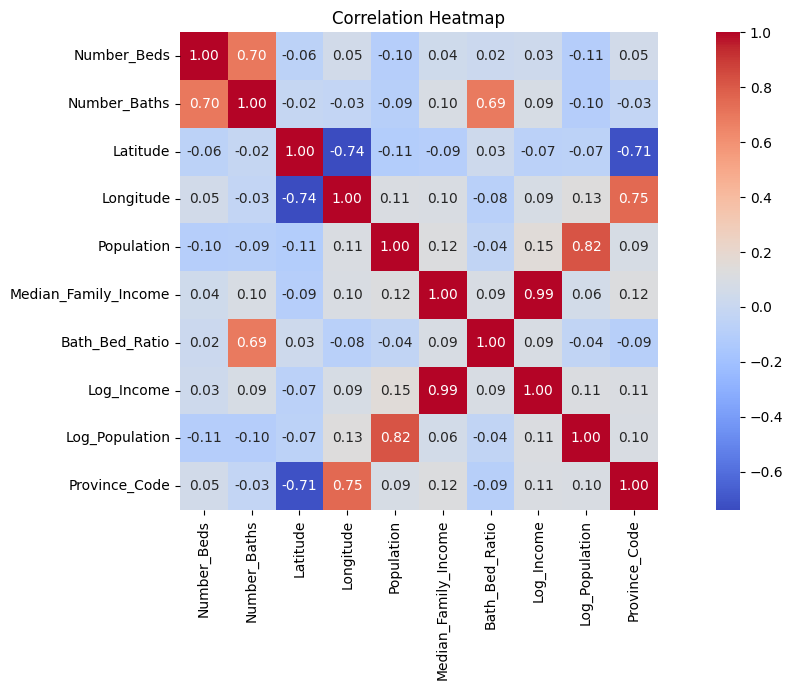

In [24]:
# ── Correlation Heatmap ─────────────────────────
corr_cols = ['Number_Beds', 'Number_Baths', 'Latitude', 'Longitude', 'Population', 'Median_Family_Income', 'Bath_Bed_Ratio', 'Log_Income', 'Log_Population', 'Province_Code']

plt.figure(figsize=(12, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../plots/10_correlation_heatmap.png", dpi=150)
plt.show()

In [26]:
# ── Save featured dataset ─────────
featured_df = df[['City', 'Number_Beds', 'Number_Baths', 'Latitude',  'Longitude', 'Bath_Bed_Ratio', 'Log_Income', 'Log_Population', 'Province_Code', 'Log_Price']]

featured_df.to_csv("../dataset/processed/housing_featured.csv", index=False)
featured_df.shape

(26646, 10)